In [1]:
import nltk
import pandas as pd
import numpy as np
import re
import os
import nltk
from sklearn.svm import SVC
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import issparse
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

In [3]:
train_data = pd.read_csv(r'C:\Users\user\Desktop\SMS_train.csv', encoding='latin1')
test_data = pd.read_csv(r'C:\Users\user\Desktop\SMS_test.csv', encoding='latin1')

In [4]:
train_data.head()

,S. No.,Message_body,Label
0,1,Rofl. Its true to its name,Non-Spam
1,2,The guy did some bitching but I acted like i'd...,Non-Spam
2,3,"Pity, * was in mood for that. So...any other s...",Non-Spam
3,4,Will ü b going to esplanade fr home?,Non-Spam
4,5,This is the 2nd time we have tried 2 contact u...,Spam


In [29]:
train_data.shape

(957, 3)

In [30]:
test_data.head()

,S. No.,Message_body,Label
0,1,"UpgrdCentre Orange customer, you may now claim...",Spam
1,2,"Loan for any purpose £500 - £75,000. Homeowner...",Spam
2,3,Congrats! Nokia 3650 video camera phone is you...,Spam
3,4,URGENT! Your Mobile number has been awarded wi...,Spam
4,5,Someone has contacted our dating service and e...,Spam


In [31]:
test_data.shape

(125, 3)

In [32]:
train_data.isnull().sum()

S. No.          0
Message_body    0
Label           0
dtype: int64

In [5]:
data = pd.concat([train_data ,test_data], ignore_index = True)

# Preprocessing 

In [6]:
stopwords = set(nltk.corpus.stopwords.words('english'))

def preprocess_text(text):
    
    # Remove special characters and digits
    text = re.sub(r'\W',' ', text)
    text = re.sub(r'\d+',' ', text)
    # Lowercasing
    text = text.lower()
    # Tokenization 
    tokens = nltk.word_tokenize(text)
    # define stop words
    filtered_tokens = [word for word in tokens if word not in stopwords]
    # join tokens back into string 
    preprocessed_text = ' '.join(filtered_tokens)
    return preprocessed_text

In [8]:
# Replacing message body with processed message body

data['Message_body'] = data['Message_body'].apply(preprocess_text)
data

,S. No.,Message_body,Label
0,1,rofl true name,Non-Spam
1,2,guy bitching acted like interested buying some...,Non-Spam
2,3,pity mood suggestions,Non-Spam
3,4,ü b going esplanade fr home,Non-Spam
4,5,nd time tried contact u u pound prize claim ea...,Spam
...,...,...,...
1077,121,wonders world th th ur style th ur smile th ur...,Non-Spam
1078,122,try something dear read something exams,Non-Spam
1079,123,sun ah thk mayb dun anythin thk book e lesson ...,Non-Spam
1080,124,symptoms u love u like listening songs u get s...,Non-Spam


# Splitting Data

In [9]:
# Splitting the data into training and testing sets
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(data, test_size=0.20, random_state=10)

## Vectorization

In [10]:
# Vectorization using TF-IDF
vectorizer = TfidfVectorizer(max_features = 4000)

# fit and transform the training data 
x_train = vectorizer.fit_transform(train_data['Message_body'])
y_train = train_data['Label']

# fit and transform the test data 
x_test = vectorizer.transform(test_data['Message_body'])
y_test = test_data['Label']

In [11]:
x_test.todense().shape

(217, 2641)

In [12]:
x_train.todense().shape

(865, 2641)

# Visualisation of data labels 

## Train Set Labels Plot

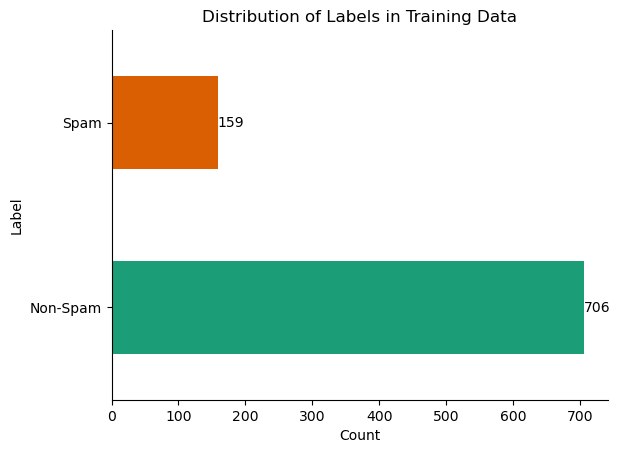

In [13]:
ax = train_data.groupby('Label').size().plot(kind = 'barh', color = sns.color_palette('Dark2'))
# Setting the labels and title
plt.xlabel('Count')
plt.ylabel('Label')
plt.title('Distribution of Labels in Training Data')
# Customize the plot's appearance
plt.gca().spines[['top','right']].set_visible(False)

# Adding value labels to the bar 
for i in ax.containers:
    ax.bar_label(i)
    
plt.show()

## Test set labels plot

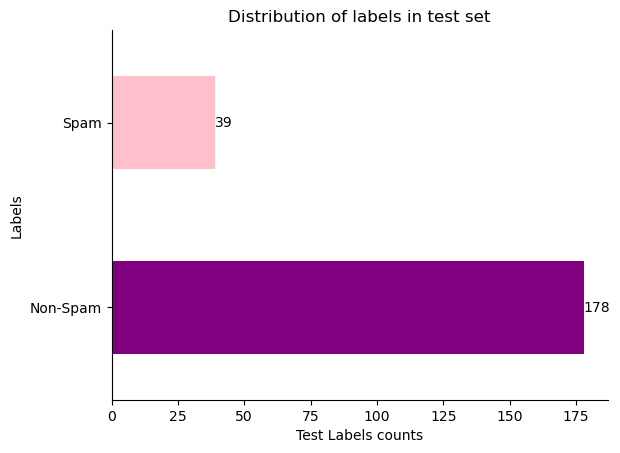

In [14]:
ax = test_data.groupby('Label').size().plot(kind = 'barh', color = sns.color_palette(['purple','pink']))

plt.xlabel('Test Labels counts')
plt.ylabel('Labels')
plt.title('Distribution of labels in test set')

plt.gca().spines[['top','right']].set_visible(False)

for i in ax.containers:
    ax.bar_label(i)

plt.show()

# Machine Learning Classification Models comparison

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Encoding labels into 0 and 1 

from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

y_train_encoded = labelencoder.fit_transform(y_train)
y_test_encoded = labelencoder.fit_transform(y_test)

In [18]:
y_test_encoded

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0])

## Models

In [23]:
models = {
     'SVM':{
        'model': SVC(),
        'params': {
            'kernel': ['linear'],
            'C': [10, 100],
            'gamma':['scale'],
        }
    },
   
    
    'LogisticRegression': {
        'model': LogisticRegression(max_iter = 50),
        'params':{
            'C': [0.01, 0.1],
        }
    },
    
    'Multinomial NB': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.01, 0.1],
        }
    },
    
    'Random Forest':{
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [10, 20],
            'min_samples_split': [5, 10]
        }
         
    },
    
    'Gradient Boosting': {
          'model': GradientBoostingClassifier(),
          'params': {
              'n_estimators': [100, 200],
              'learning_rate': [0.01,0.1],
              'max_depth': [5, 7]
          }
      },
    
        'LightGBM': {
            'model': LGBMClassifier(verbose=-1),
            'params': {
                'n_estimators': [50, 100],
                'learning_rate': [0.01, 0.1],
                'max_depth': [5, 10]
            }
      }   
}

### Function to train all models with different parameters 

In [21]:
def evaluate_model(model, params_grid, x_train, y_train, x_test, y_test, cv_splits = 5):
    
    grid_search = GridSearchCV(model, params_grid, cv = cv_splits, scoring = 'accuracy')
    grid_search.fit(x_train, y_train)
    
    best_model = grid_search.best_estimator_
    
    # Mean cross-validation score
    mean_cv_score = grid_search.best_score_
    
    # train the best model on the entire dataset
    best_model.fit(x_train, y_train)
    
    # Predictions on the dataset 
    y_pred = best_model.predict(x_test)
    
    # Accuracy of the model 
    test_accuracy = accuracy_score(y_pred, y_test)
    class_report = classification_report(y_pred, y_test)
    conf_matrix = confusion_matrix(y_pred, y_test)
    
    return mean_cv_score, test_accuracy, class_report, conf_matrix, grid_search.best_params_

In [24]:
results = {}

for model_name, model_info in models.items():
    
    mean_cv_score, test_accuracy, class_report, conf_matrix, best_params_ = evaluate_model(model_info['model'],model_info['params'], x_train, y_train_encoded, x_test, y_test_encoded, cv_splits = 5)
  
    results[model_name] = {
        'Mean CV score': mean_cv_score,
        'Test Accuracy': test_accuracy,
        'Classification Report': class_report,
        'Confusion Matrix': conf_matrix,
        'Best Params': best_params_
    }

### Model Comparison and Best Model Selection

Model: SVM
BestParams: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Mean CV score: 0.9584
est Accuracy: 0.9724

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       178
           1       0.92      0.92      0.92        39

    accuracy                           0.97       217
   macro avg       0.95      0.95      0.95       217
weighted avg       0.97      0.97      0.97       217



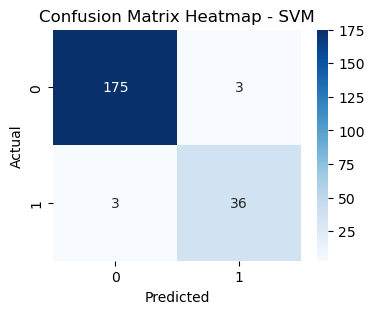

Model: LogisticRegression
BestParams: {'C': 0.01}
Mean CV score: 0.8162
est Accuracy: 0.8203

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.82      0.90       217
           1       0.00      0.00      0.00         0

    accuracy                           0.82       217
   macro avg       0.50      0.41      0.45       217
weighted avg       1.00      0.82      0.90       217



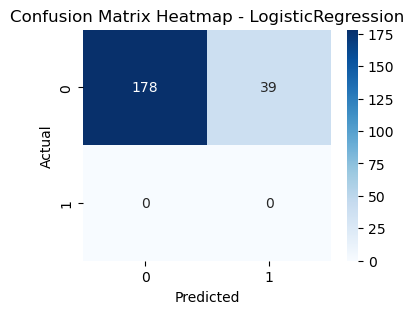

Model: Multinomial NB
BestParams: {'alpha': 0.1}
Mean CV score: 0.9676
est Accuracy: 0.9585

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       171
           1       0.97      0.83      0.89        46

    accuracy                           0.96       217
   macro avg       0.96      0.91      0.93       217
weighted avg       0.96      0.96      0.96       217



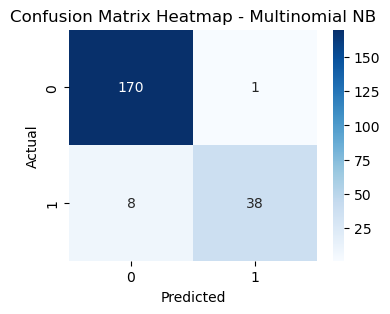

Model: Random Forest
BestParams: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
Mean CV score: 0.9376
est Accuracy: 0.9309

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       189
           1       0.67      0.93      0.78        28

    accuracy                           0.93       217
   macro avg       0.83      0.93      0.87       217
weighted avg       0.95      0.93      0.94       217



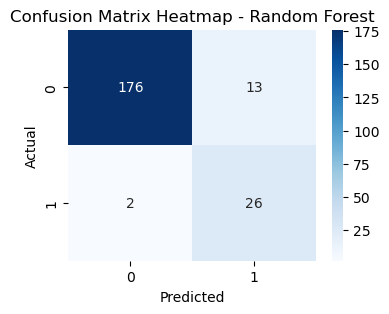

Model: Gradient Boosting
BestParams: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Mean CV score: 0.9503
est Accuracy: 0.9309

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       185
           1       0.72      0.88      0.79        32

    accuracy                           0.93       217
   macro avg       0.85      0.91      0.87       217
weighted avg       0.94      0.93      0.93       217



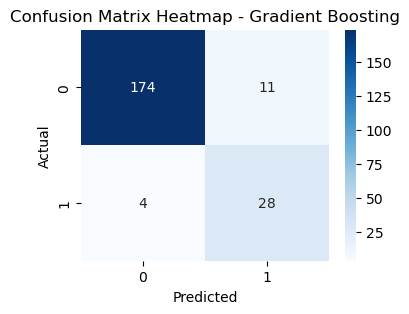

Model: LightGBM
BestParams: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100}
Mean CV score: 0.9341
est Accuracy: 0.9309

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       185
           1       0.72      0.88      0.79        32

    accuracy                           0.93       217
   macro avg       0.85      0.91      0.87       217
weighted avg       0.94      0.93      0.93       217



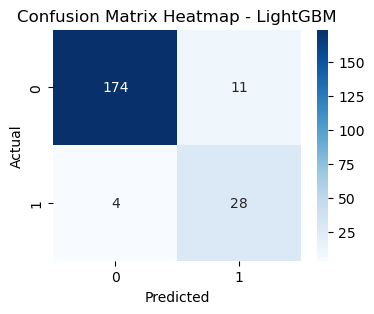

Best model is: SVM with accuracy: 0.9723502304147466


In [25]:
best_model_name = None
best_test_accuracy = 0 

for model_name, result in results.items():
    
    print(f"Model: {model_name}")
    print(f"BestParams: {result['Best Params']}")
    print(f"Mean CV score: {result['Mean CV score']:.4f}")
    print(f"est Accuracy: {result['Test Accuracy']:.4f}")
    print(f"\nClassification Report:") 
    print(result['Classification Report'])
    
    plt.figure(figsize = (4,3))
    sns.heatmap(result['Confusion Matrix'], annot = True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix Heatmap - {model_name}')
    plt.show()
          
    if result['Test Accuracy'] > best_test_accuracy:
           best_test_accuracy = result['Test Accuracy']
           best_model_name = model_name

print(f'Best model is: {best_model_name} with accuracy: {best_test_accuracy}')

 From the accuracy and the confusion matrix heatmap we can see that the best model is SVM with accuracy = 0.97